In [2]:
"""
EDA - g2g_emissions.csv: Emissioni aviazione ECAC (Gate-to-Gate)
================================================================
Dataset: EUROCONTROL Gate-to-Gate emissions
Copertura: 45 stati europei + 7 aggregati di rete, mensile 2019–2024
Inquinanti: CO₂ (tonnellate), NOx (kg), SOx (kg)

Struttura dell'EDA:
  1. Setup, caricamento, pulizia
  2. Overview e struttura del dataset
  3. Trend ECAC mensile (CO₂, NOx, SOx)
  4. Stagionalità e decomposizione
  5. Scomposizione per market segment
  6. Scomposizione per flight phase
  7. Scomposizione per flight type (D/A/O/I)
  8. Top 15 stati per emissioni
  9. Impatto COVID: calo e ripresa per stato
 10. Efficienza: CO₂ per volo nel tempo
 11. Matrice correlazione inquinanti
 12. Small multiples: top 12 stati
"""

# =============================================================================
# 1. SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#F7F7F5",
    "axes.facecolor":   "#F7F7F5",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#DDDDDD",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   11,
    "axes.labelsize":   10,
})

FILE = "g2g_emissions.csv"
df = pd.read_csv(FILE)

# Country code → name mapping (per label leggibili)
CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

# Separazione stati vs aggregati di rete
NETWORK_AREAS = {"ECAC","EEA","EU27","EU27+EFTA","EUROCONTROL","FLYING_GREEN","RP3"}
df_state = df[df["LEVEL"] == "STATE"].copy()
df_net   = df[df["LEVEL"] == "NETWORK"].copy()

# Data mensile
df_state["DATE"] = pd.to_datetime(
    df_state["YEAR"].astype(str) + "-" + df_state["MONTH"].astype(str).str.zfill(2) + "-01"
)
df_net["DATE"] = pd.to_datetime(
    df_net["YEAR"].astype(str) + "-" + df_net["MONTH"].astype(str).str.zfill(2) + "-01"
)

print(f"Shape totale:     {df.shape}")
print(f"Righe STATE:      {len(df_state):,}")
print(f"Righe NETWORK:    {len(df_net):,}")
print(f"Stati:            {df_state['AREA'].nunique()}")
print(f"Periodo:          {df['YEAR'].min()}–{df['YEAR'].max()}")
print(f"Nessun valore nullo ✓") if df.isnull().sum().sum() == 0 else print("⚠ Ci sono null")

Shape totale:     (511627, 12)
Righe STATE:      456,006
Righe NETWORK:    55,621
Stati:            45
Periodo:          2019–2024
Nessun valore nullo ✓


In [3]:
# =============================================================================
# 2. OVERVIEW
# =============================================================================
print("\n" + "="*60)
print("OVERVIEW NUMERICA")
print("="*60)
for col in ["NB_FLIGHTS","CO2_TONS","NOX_KG","SOX_KG"]:
    tot = df_state[col].sum()
    print(f"  {col:<14} totale: {tot:>18,.0f}")


OVERVIEW NUMERICA
  NB_FLIGHTS     totale:      1,168,578,058
  CO2_TONS       totale:      1,799,264,109
  NOX_KG         totale:      9,011,933,303
  SOX_KG         totale:        479,663,425


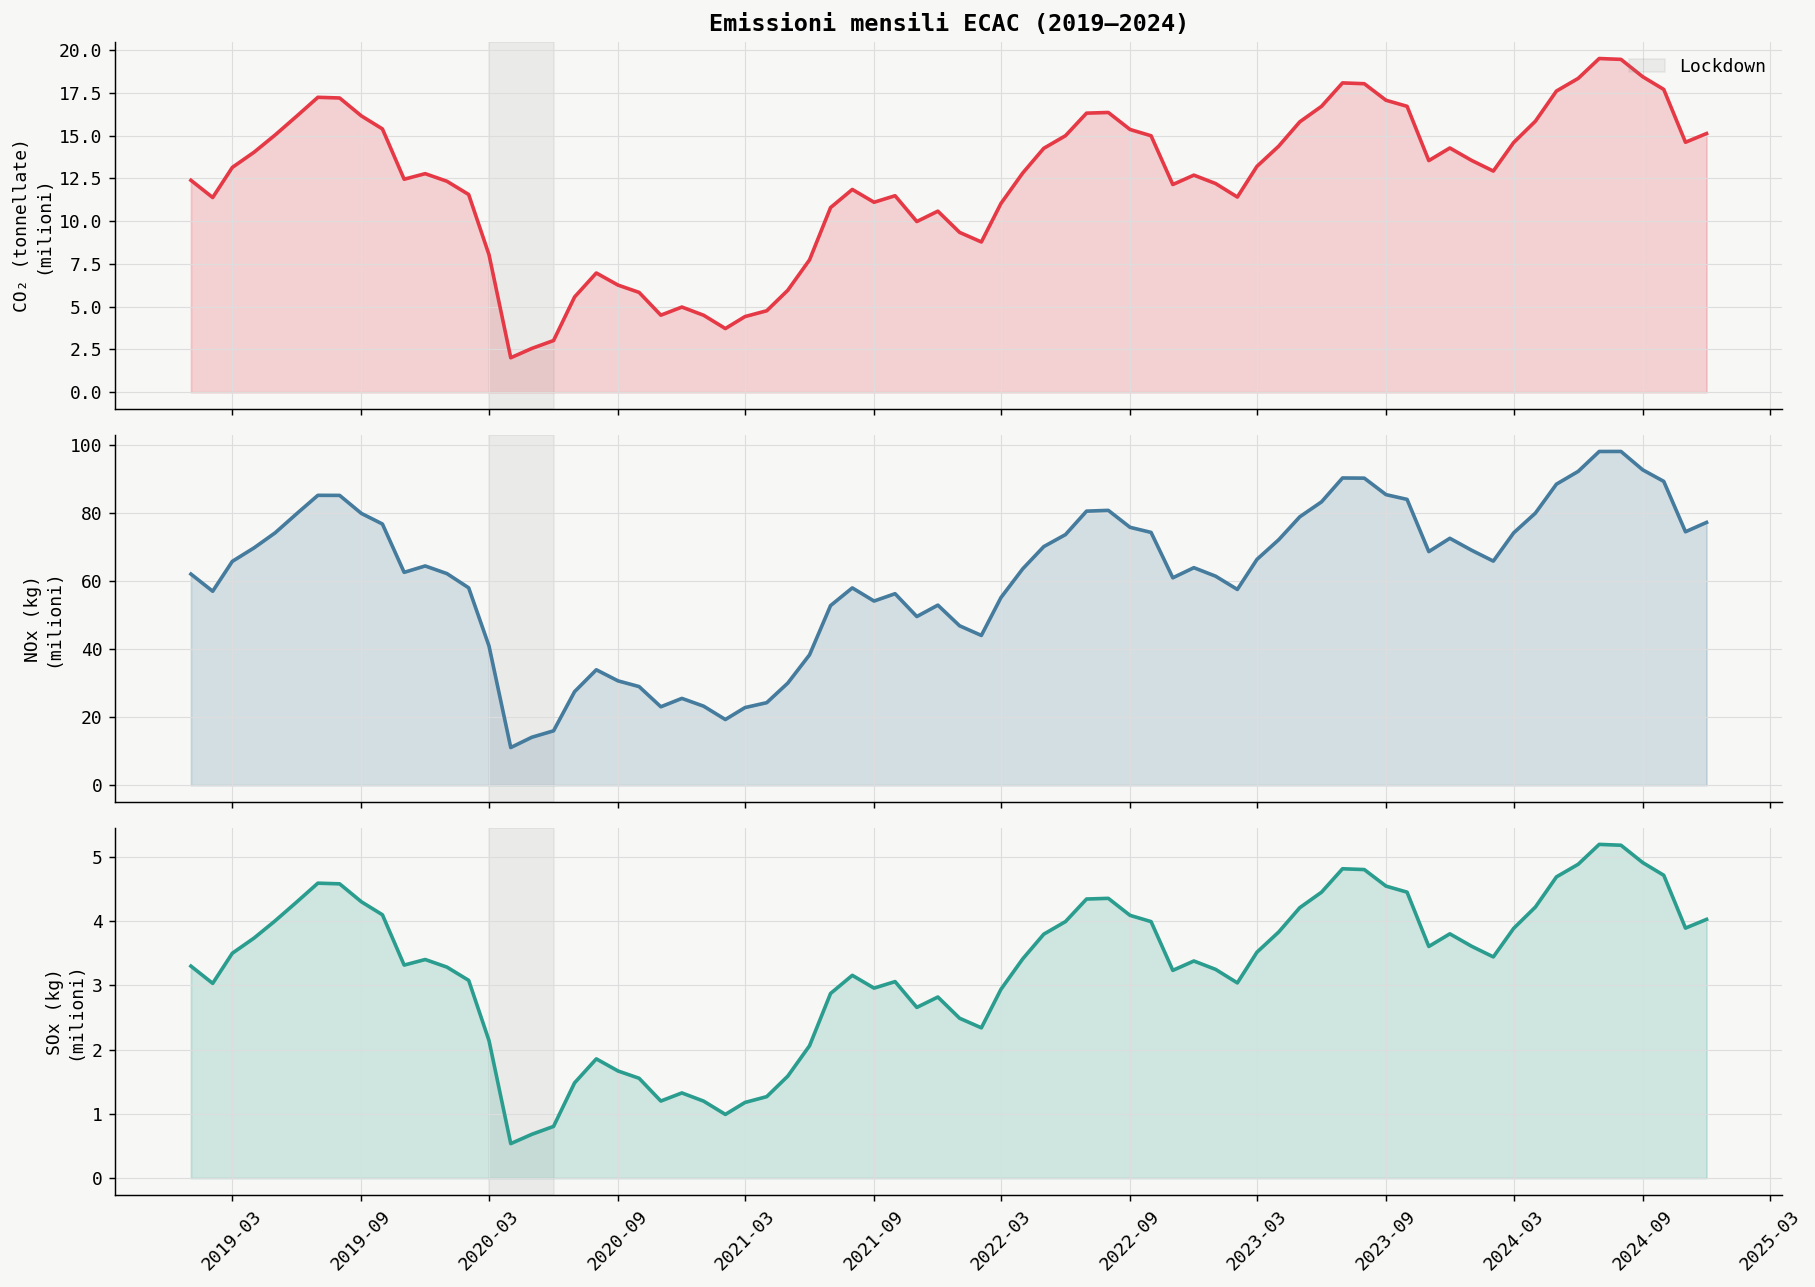

[Salvato] eda_em_01_ecac_trend.png


In [4]:
# =============================================================================
# 3. TREND ECAC MENSILE (CO₂, NOx, SOx)
# =============================================================================
ecac = df_net[df_net["AREA"] == "ECAC"].copy()
ecac_monthly = ecac.groupby("DATE")[["NB_FLIGHTS","CO2_TONS","NOX_KG","SOX_KG"]].sum().reset_index()
ecac_monthly = ecac_monthly.sort_values("DATE")
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
pollutants = [
    ("CO2_TONS", "CO₂ (tonnellate)", "#E63946"),
    ("NOX_KG",   "NOx (kg)",         "#457B9D"),
    ("SOX_KG",   "SOx (kg)",         "#2A9D8F"),
]
 
for ax, (col, label, color) in zip(axes, pollutants):
    ax.fill_between(ecac_monthly["DATE"], ecac_monthly[col] / 1e6,
                    alpha=0.2, color=color)
    ax.plot(ecac_monthly["DATE"], ecac_monthly[col] / 1e6,
            color=color, lw=2)
    ax.set_ylabel(f"{label}\n(milioni)")
    ax.axvspan("2020-03-01","2020-06-01", alpha=0.1, color="grey", label="Lockdown")
    if ax == axes[0]:
        ax.set_title("Emissioni mensili ECAC (2019–2024)", fontweight="bold", fontsize=13)
        ax.legend(frameon=False, loc="upper right")
 
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_em_01_ecac_trend.png")
plt.show()
print("[Salvato] eda_em_01_ecac_trend.png")

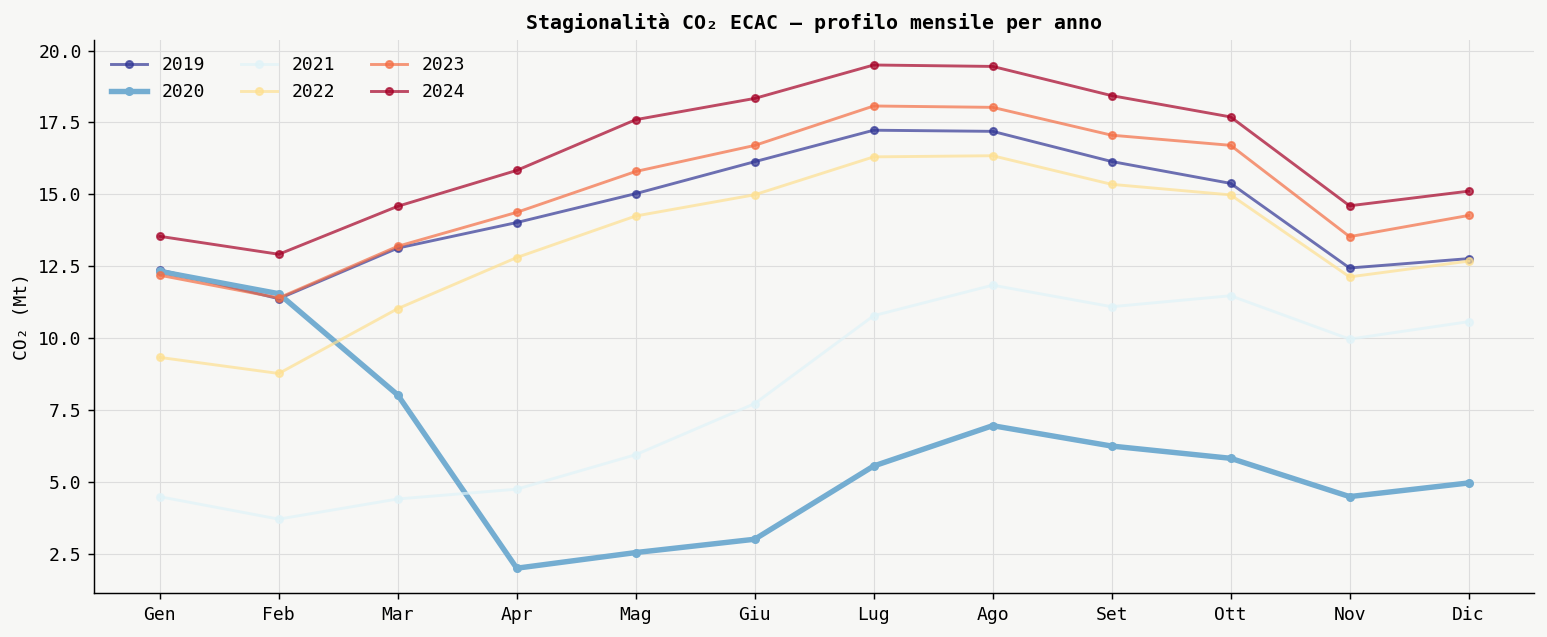

[Salvato] eda_em_02_seasonality.png


In [5]:
# =============================================================================
# 4. STAGIONALITÀ: media mensile per anno
# =============================================================================
ecac_season = ecac.groupby(["YEAR","MONTH"])["CO2_TONS"].sum().reset_index()
piv_season = ecac_season.pivot(index="MONTH", columns="YEAR", values="CO2_TONS")

fig, ax = plt.subplots(figsize=(12, 5))
palette_yr = cm.get_cmap("RdYlBu_r", len(piv_season.columns))
for i, yr in enumerate(piv_season.columns):
    style = {"lw": 3, "alpha": 1.0} if yr == 2020 else {"lw": 1.6, "alpha": 0.7}
    ax.plot(piv_season.index, piv_season[yr] / 1e6, marker="o", ms=4,
            color=palette_yr(i), label=str(yr), **style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Gen","Feb","Mar","Apr","Mag","Giu",
                     "Lug","Ago","Set","Ott","Nov","Dic"])
ax.set_ylabel("CO₂ (Mt)")
ax.set_title("Stagionalità CO₂ ECAC — profilo mensile per anno", fontweight="bold")
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("eda_em_02_seasonality.png")
plt.show()
print("[Salvato] eda_em_02_seasonality.png")

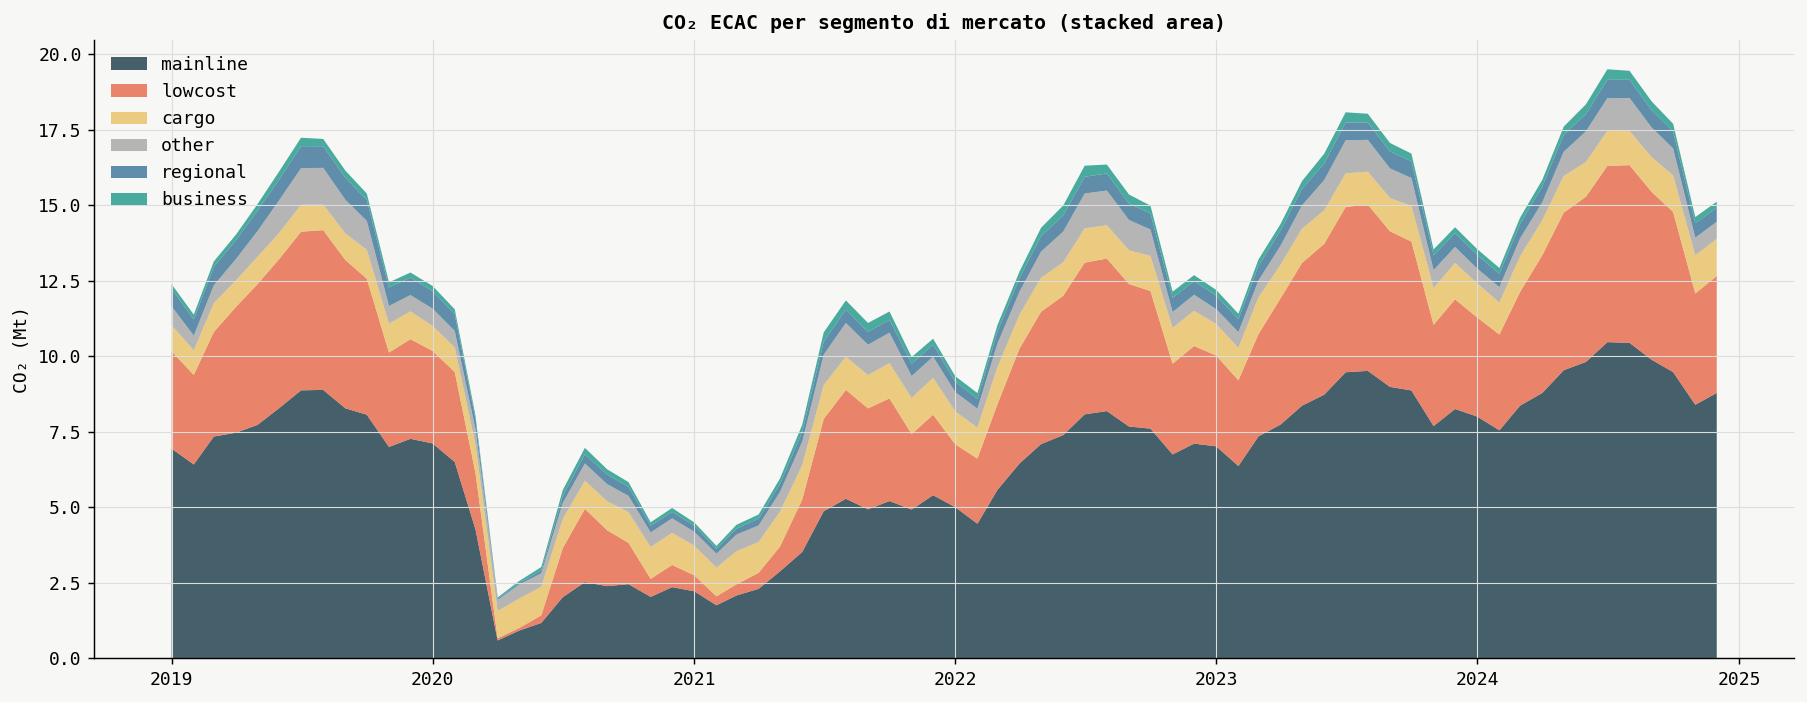

[Salvato] eda_em_03_segment.png


In [6]:
# =============================================================================
# 5. SCOMPOSIZIONE PER MARKET SEGMENT
# =============================================================================
seg = df_net[df_net["AREA"] == "ECAC"].groupby(
    ["DATE","MARKET_SEGMENT"]
)["CO2_TONS"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5.5))
seg_piv = seg.pivot(index="DATE", columns="MARKET_SEGMENT", values="CO2_TONS").fillna(0) / 1e6
order = seg_piv.sum().sort_values(ascending=False).index
colors_seg = {"mainline":"#264653","lowcost":"#E76F51","business":"#2A9D8F",
              "cargo":"#E9C46A","regional":"#457B9D","other":"#AAAAAA"}
ax.stackplot(seg_piv.index, *[seg_piv[c] for c in order],
             labels=order, colors=[colors_seg.get(c,"#999") for c in order], alpha=0.85)
ax.set_ylabel("CO₂ (Mt)")
ax.set_title("CO₂ ECAC per segmento di mercato (stacked area)", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig("eda_em_03_segment.png")
plt.show()
print("[Salvato] eda_em_03_segment.png")

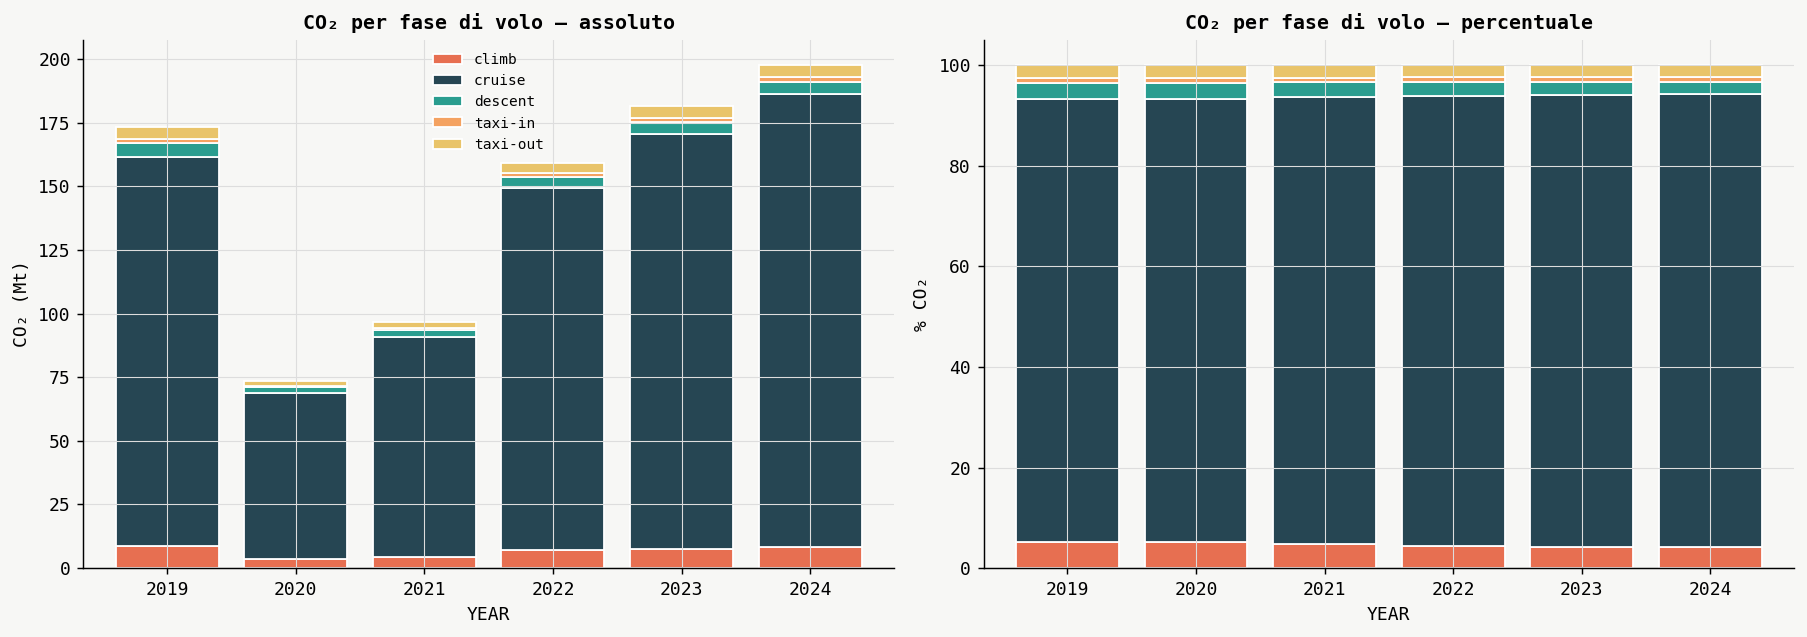

[Salvato] eda_em_04_phase.png


In [7]:
# =============================================================================
# 6. SCOMPOSIZIONE PER FLIGHT PHASE
# =============================================================================
phase = df_net[df_net["AREA"] == "ECAC"].groupby(
    ["YEAR","FLIGHT_PHASE"]
)["CO2_TONS"].sum().reset_index()

phase_piv = phase.pivot(index="YEAR", columns="FLIGHT_PHASE", values="CO2_TONS") / 1e6
phase_pct = phase_piv.div(phase_piv.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ph = {"cruise":"#264653","climb":"#E76F51","descent":"#2A9D8F",
             "taxi-out":"#E9C46A","taxi-in":"#F4A261"}

# Assoluti
phase_piv.plot(kind="bar", stacked=True, ax=axes[0],
               color=[colors_ph.get(c,"#999") for c in phase_piv.columns],
               edgecolor="white", width=0.8)
axes[0].set_ylabel("CO₂ (Mt)")
axes[0].set_title("CO₂ per fase di volo — assoluto", fontweight="bold")
axes[0].legend(fontsize=8, frameon=False)
axes[0].tick_params(axis="x", rotation=0)

# Percentuale
phase_pct.plot(kind="bar", stacked=True, ax=axes[1],
               color=[colors_ph.get(c,"#999") for c in phase_pct.columns],
               edgecolor="white", width=0.8, legend=False)
axes[1].set_ylabel("% CO₂")
axes[1].set_title("CO₂ per fase di volo — percentuale", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("eda_em_04_phase.png")
plt.show()
print("[Salvato] eda_em_04_phase.png")

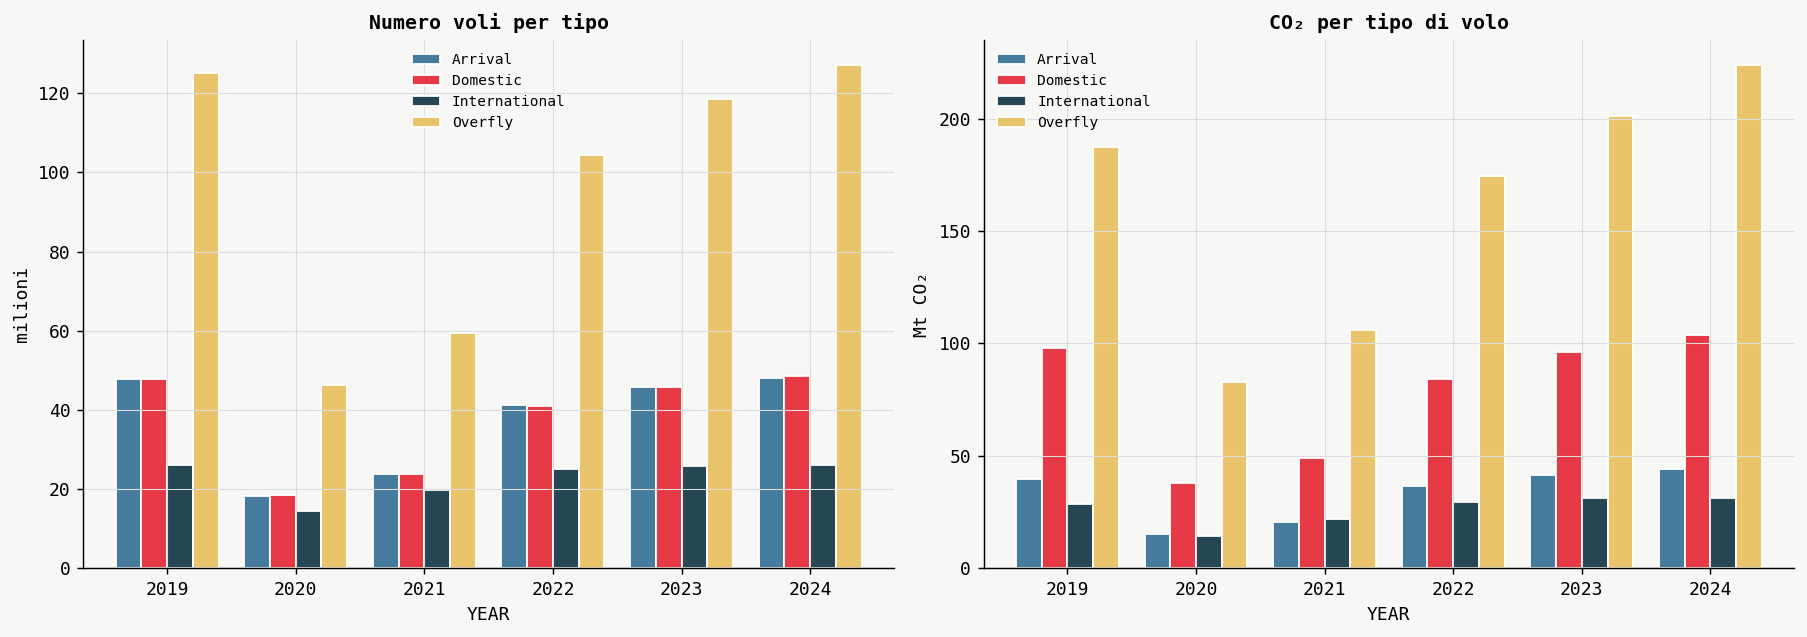

[Salvato] eda_em_05_flight_type.png


In [8]:
# =============================================================================
# 7. SCOMPOSIZIONE PER FLIGHT TYPE (D/A/O/I)
# =============================================================================
ft_labels = {"D":"Domestic","A":"Arrival","I":"International","O":"Overfly"}
ft = df_state.groupby(["YEAR","FLIGHT_TYPE"])[["CO2_TONS","NB_FLIGHTS"]].sum().reset_index()
ft["label"] = ft["FLIGHT_TYPE"].map(ft_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ft = {"Domestic":"#E63946","Arrival":"#457B9D","International":"#264653","Overfly":"#E9C46A"}

for ax, metric, title in zip(axes,
    ["NB_FLIGHTS","CO2_TONS"],
    ["Numero voli per tipo","CO₂ per tipo di volo"]):
    piv = ft.pivot(index="YEAR", columns="label", values=metric)
    piv = piv / (1e6 if metric=="CO2_TONS" else 1e6)
    piv.plot(kind="bar", ax=ax, color=[colors_ft[c] for c in piv.columns],
             edgecolor="white", width=0.8)
    unit = "Mt CO₂" if metric=="CO2_TONS" else "milioni"
    ax.set_ylabel(unit)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("eda_em_05_flight_type.png")
plt.show()
print("[Salvato] eda_em_05_flight_type.png")

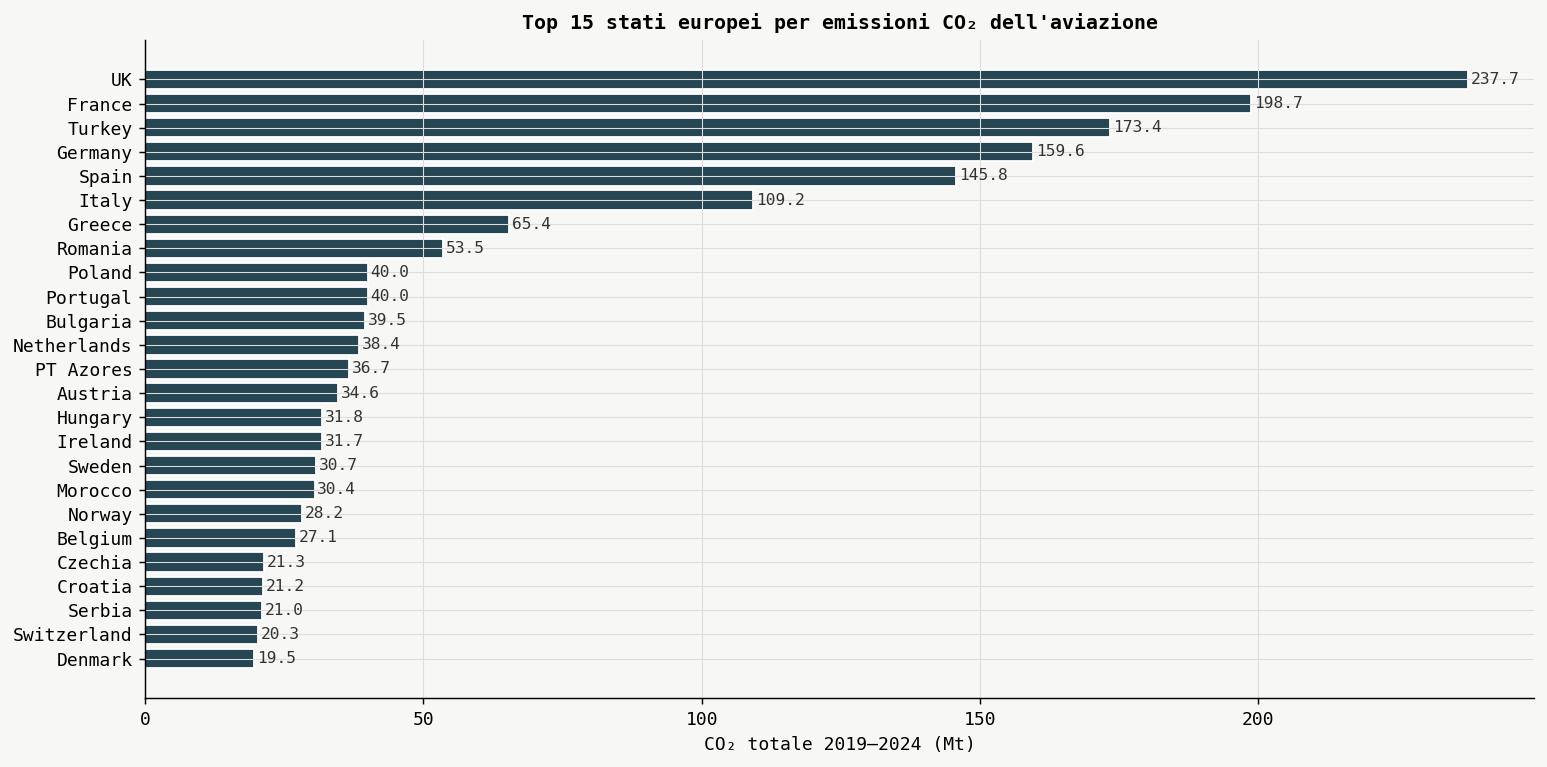

[Salvato] eda_em_06_top_states.png


In [9]:
# =============================================================================
# 8. TOP 15 STATI PER EMISSIONI CO₂ TOTALI (2019–2024)
# =============================================================================
state_tot = (
    df_state.groupby("AREA")["CO2_TONS"].sum()
    .reset_index()
    .sort_values("CO2_TONS", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_TONS"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("CO₂ totale 2019–2024 (Mt)")
ax.set_title("Top 15 stati europei per emissioni CO₂ dell'aviazione", fontweight="bold")

# Annota valore
for bar, val in zip(bars, state_tot["CO2_TONS"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("eda_em_06_top_states.png")
plt.show()
print("[Salvato] eda_em_06_top_states.png")

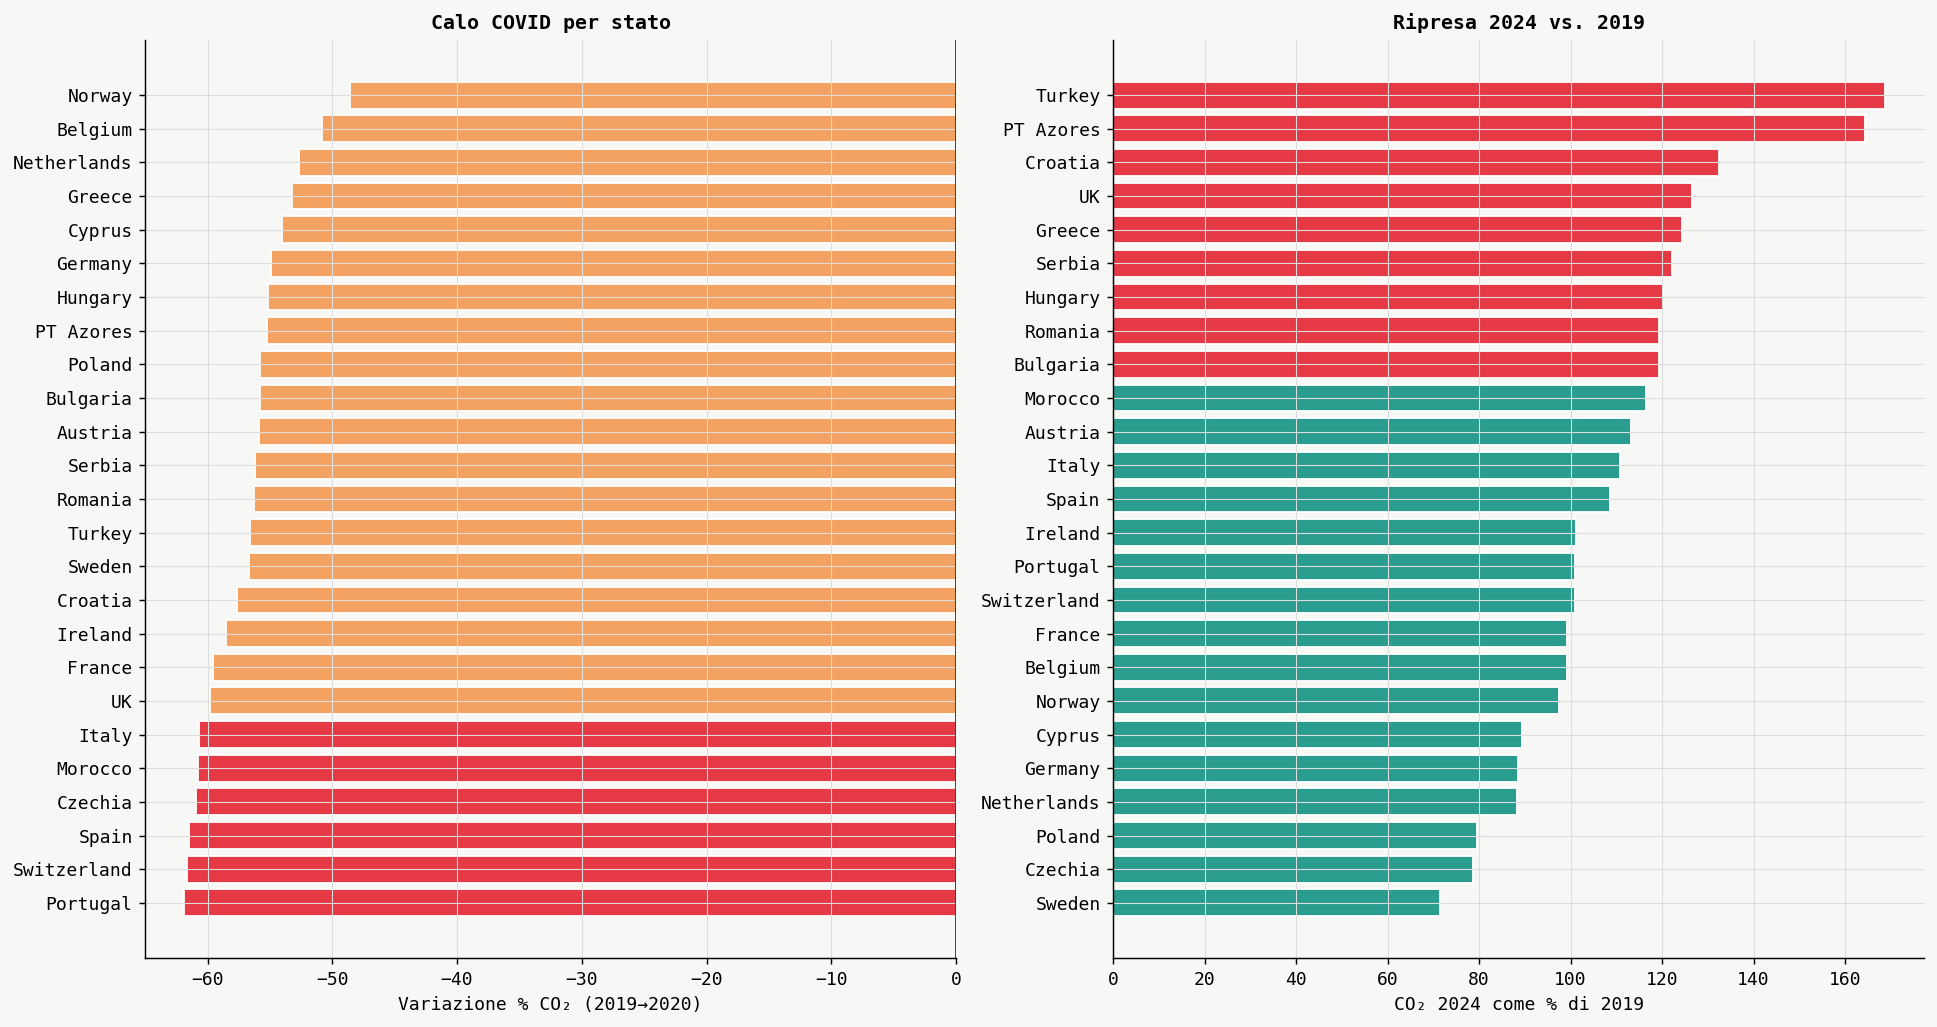

[Salvato] eda_em_07_covid_recovery.png

  Calo COVID medio:     -55.6%
  Calo COVID mediano:   -56.2%
  Stati con CO₂ 2024 ≥ 2019: 27/45
  Media recovery 2024:  382.4%


YEAR,2019,2020,2021,2022,2023,2024,covid_drop,recovery_24,name
AREA,,,,,,,,,
AL,885581.8,441057.0,608600.4,962081.8,1151232.0,1435780.0,-50.195792,162.128445,Albania
AM,558922.4,227041.8,227003.4,378324.2,415584.6,495389.4,-59.378654,88.632948,Armenia
AT,6801463.8,3000902.8,3423235.0,6235304.0,7415195.8,7704386.4,-55.878574,113.275416,Austria
AZ,588867.0,429594.2,1129446.0,2664367.6,3682919.2,5152305.8,-27.047330,874.952375,Azerbaijan
BA,1995566.0,966799.4,1216968.8,1959601.6,2293682.4,2524985.8,-51.552622,126.529807,Bosnia
BE,5587743.2,2747943.6,3100483.4,4779851.8,5361314.6,5539438.8,-50.821942,99.135529,Belgium
BG,7589058.4,3354301.8,4042363.2,6983323.4,8463949.2,9050347.6,-55.800817,119.255211,Bulgaria
CH,4406343.2,1690672.6,2127489.2,3666971.2,3969913.8,4444063.8,-61.630937,100.856052,Switzerland
CY,3891585.6,1787779.0,2424302.8,3247633.2,3758064.2,3480480.8,-54.060396,89.436059,Cyprus


In [17]:
# =============================================================================
# 9. IMPATTO COVID: variazione annuale CO₂ per stato
# =============================================================================
state_yearly = df_state.groupby(["AREA","YEAR"])["CO2_TONS"].sum().reset_index()
piv_yr = state_yearly.pivot(index="AREA", columns="YEAR", values="CO2_TONS")

# Calo 2019→2020
piv_yr["covid_drop"] = (piv_yr[2020] - piv_yr[2019]) / piv_yr[2019] * 100
# Ripresa 2024 vs 2019
piv_yr["recovery_24"] = piv_yr[2024] / piv_yr[2019] * 100

piv_yr = piv_yr.dropna(subset=["covid_drop","recovery_24"])
piv_yr["name"] = piv_yr.index.map(CODE2NAME)

# Solo top 25 per volume
top25_areas = piv_yr[[2019]].nlargest(25, 2019).index
piv_top = piv_yr.loc[top25_areas].sort_values("covid_drop")

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# COVID drop
axes[0].barh(piv_top["name"], piv_top["covid_drop"],
             color=["#E63946" if v < -60 else "#F4A261" if v < -40 else "#2A9D8F"
                    for v in piv_top["covid_drop"]],
             edgecolor="white")
axes[0].axvline(0, color="#333", lw=1)
axes[0].set_xlabel("Variazione % CO₂ (2019→2020)")
axes[0].set_title("Calo COVID per stato", fontweight="bold")

# Recovery 2024
piv_top_r = piv_top.sort_values("recovery_24", ascending=True)
axes[1].barh(piv_top_r["name"], piv_top_r["recovery_24"],
             color=["#E63946" if v > 118 else "#2A9D8F"
                    for v in piv_top_r["recovery_24"]],
             edgecolor="white")
#axes[1].axvline(100, color="#333", lw=1.2, ls="--", label="Livello 2019")
axes[1].set_xlabel("CO₂ 2024 come % di 2019")
axes[1].set_title("Ripresa 2024 vs. 2019", fontweight="bold")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("eda_em_07_covid_recovery.png")
plt.show()
print("[Salvato] eda_em_07_covid_recovery.png")

# Statistiche
print(f"\n  Calo COVID medio:     {piv_yr['covid_drop'].mean():.1f}%")
print(f"  Calo COVID mediano:   {piv_yr['covid_drop'].median():.1f}%")
recovered = (piv_yr["recovery_24"] >= 100).sum()
print(f"  Stati con CO₂ 2024 ≥ 2019: {recovered}/{len(piv_yr)}")
print(f"  Media recovery 2024:  {piv_yr['recovery_24'].mean():.1f}%")
piv_yr

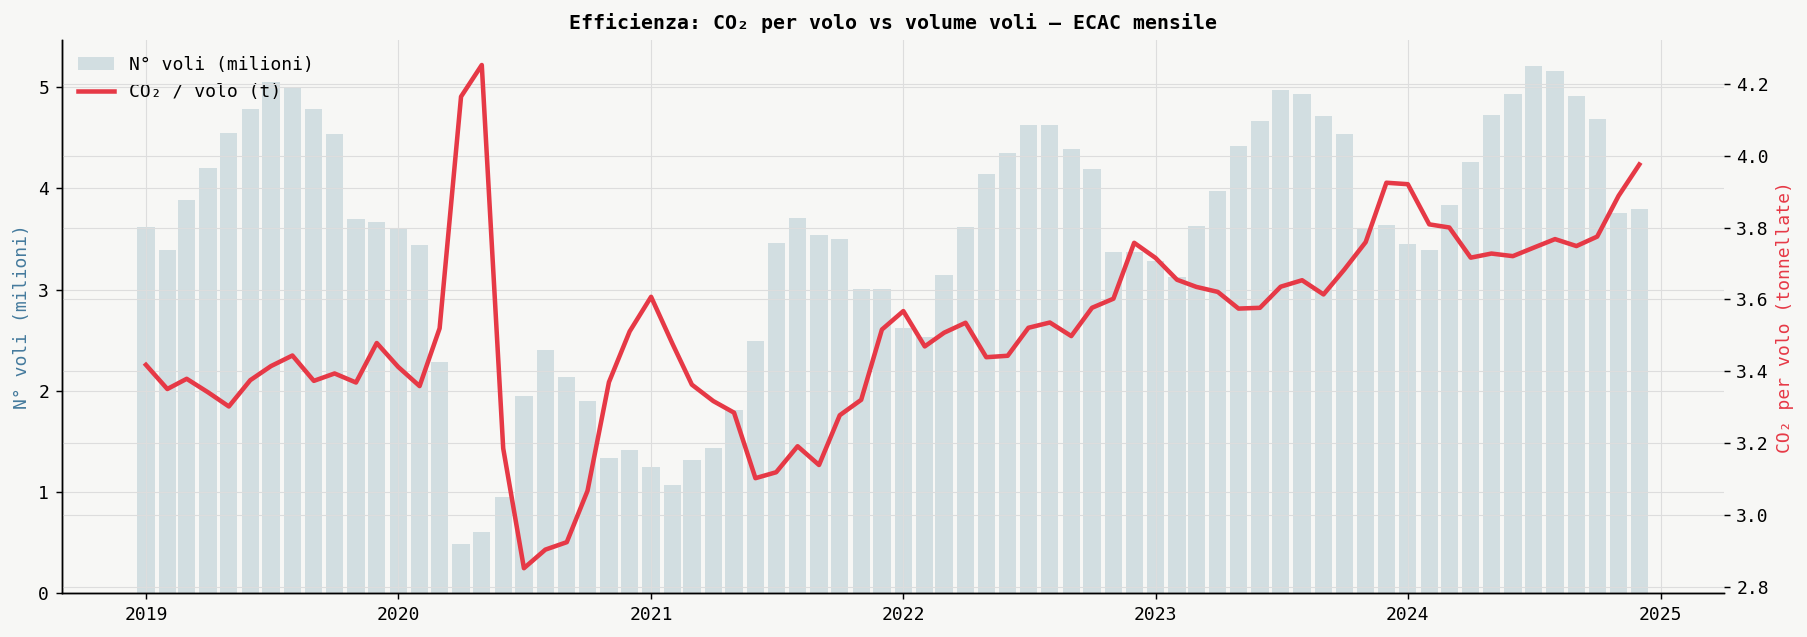

[Salvato] eda_em_08_efficiency.png


In [11]:
# =============================================================================
# 10. EFFICIENZA: CO₂ PER VOLO nel tempo (ECAC)
# =============================================================================
ecac_eff = ecac.groupby("DATE")[["CO2_TONS","NB_FLIGHTS"]].sum().reset_index()
ecac_eff["co2_per_flight"] = ecac_eff["CO2_TONS"] / ecac_eff["NB_FLIGHTS"]
ecac_eff = ecac_eff.sort_values("DATE")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(ecac_eff["DATE"], ecac_eff["NB_FLIGHTS"] / 1e6,
        width=25, color="#AEC6CF", alpha=0.5, label="N° voli (milioni)")
ax2.plot(ecac_eff["DATE"], ecac_eff["co2_per_flight"],
         color="#E63946", lw=2.5, label="CO₂ / volo (t)")

ax1.set_ylabel("N° voli (milioni)", color="#457B9D")
ax2.set_ylabel("CO₂ per volo (tonnellate)", color="#E63946")
ax1.set_title("Efficienza: CO₂ per volo vs volume voli — ECAC mensile",
              fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("eda_em_08_efficiency.png")
plt.show()
print("[Salvato] eda_em_08_efficiency.png")


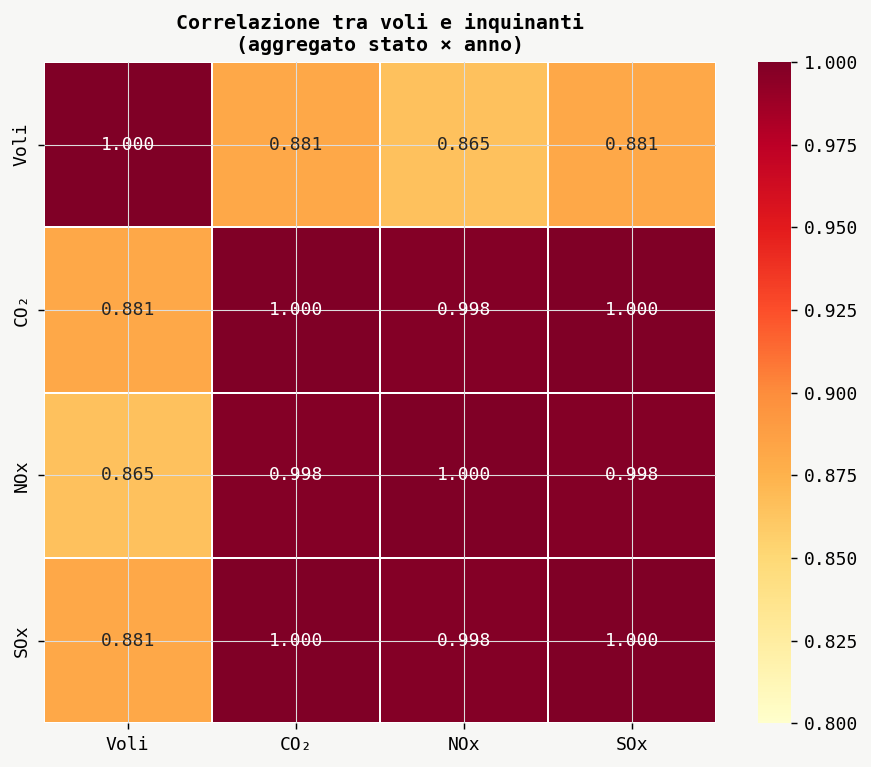

[Salvato] eda_em_09_corr_pollutants.png


In [12]:
# =============================================================================
# 11. CORRELAZIONE TRA INQUINANTI (aggregato per stato/anno)
# =============================================================================
corr_data = df_state.groupby(["AREA","YEAR"])[
    ["NB_FLIGHTS","CO2_TONS","NOX_KG","SOX_KG"]
].sum().reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = corr_data[["NB_FLIGHTS","CO2_TONS","NOX_KG","SOX_KG"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0.8, vmax=1.0, ax=ax, linewidths=1, linecolor="white",
            xticklabels=["Voli","CO₂","NOx","SOx"],
            yticklabels=["Voli","CO₂","NOx","SOx"])
ax.set_title("Correlazione tra voli e inquinanti\n(aggregato stato × anno)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("eda_em_09_corr_pollutants.png")
plt.show()
print("[Salvato] eda_em_09_corr_pollutants.png")


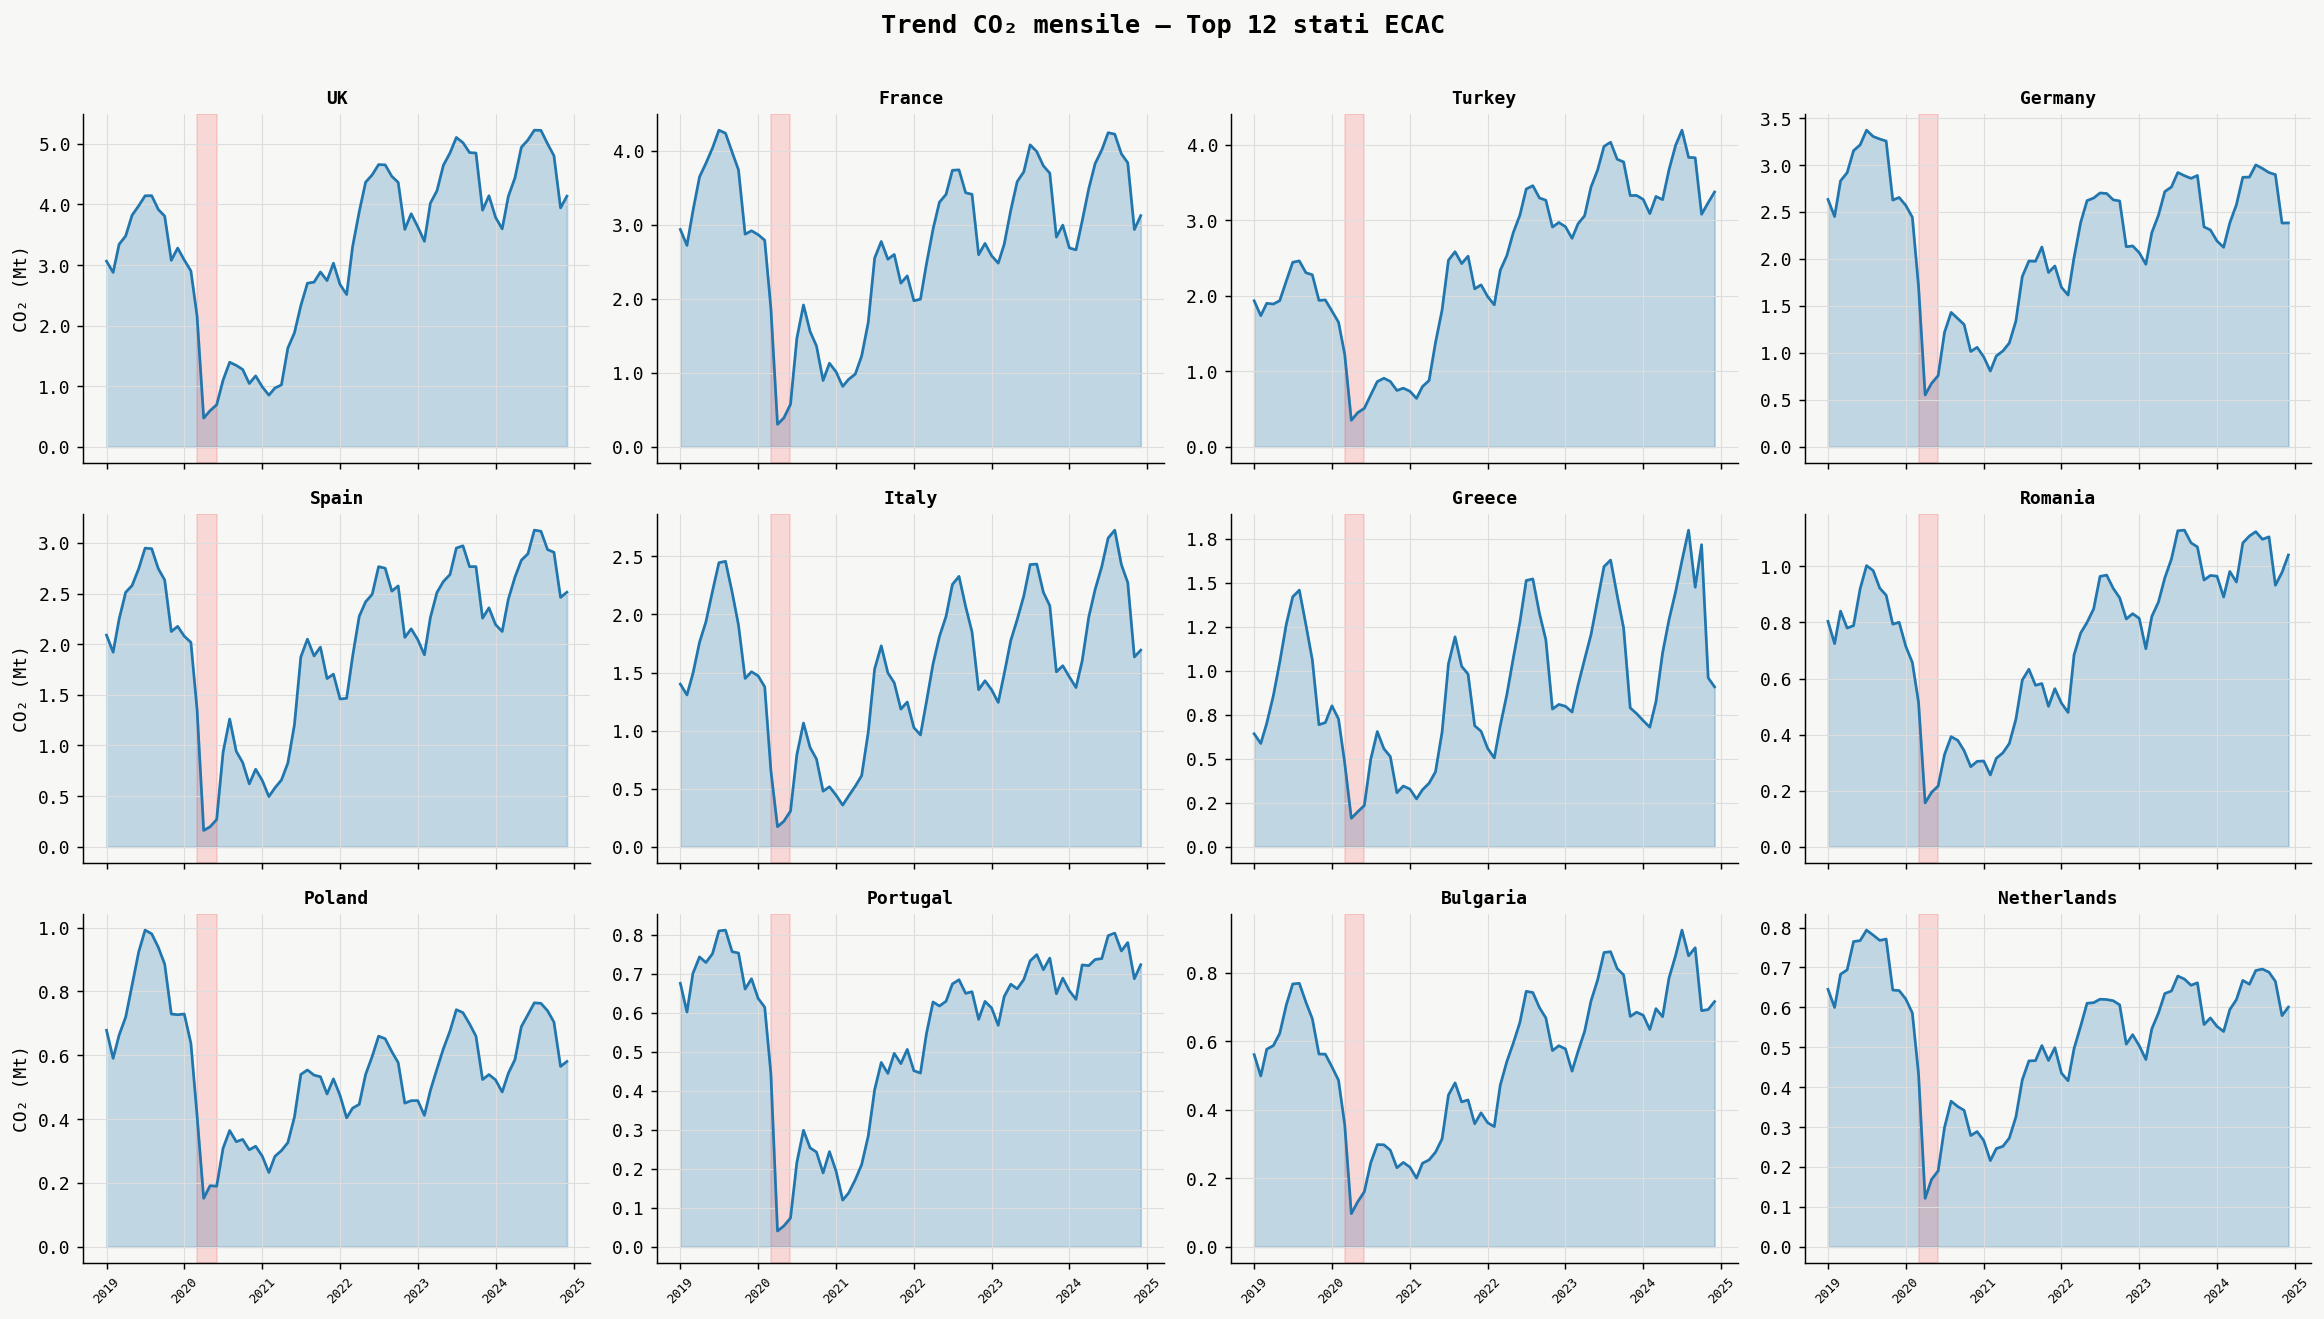

[Salvato] eda_em_10_small_multiples.png


In [13]:
# =============================================================================
# 12. SMALL MULTIPLES: Top 12 stati — trend CO₂ mensile
# =============================================================================
top12 = (
    df_state.groupby("AREA")["CO2_TONS"].sum()
    .nlargest(12).index.tolist()
)

sm_data = (
    df_state[df_state["AREA"].isin(top12)]
    .groupby(["AREA","DATE"])["CO2_TONS"].sum().reset_index()
)

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=False)
axes_flat = axes.flatten()

for i, area in enumerate(top12):
    ax = axes_flat[i]
    sub = sm_data[sm_data["AREA"] == area].sort_values("DATE")
    ax.fill_between(sub["DATE"], sub["CO2_TONS"] / 1e6, alpha=0.25, color="#2176AE")
    ax.plot(sub["DATE"], sub["CO2_TONS"] / 1e6, color="#2176AE", lw=1.5)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"),
               alpha=0.12, color="red")
    ax.set_title(CODE2NAME.get(area, area), fontweight="bold", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    if i % 4 == 0:
        ax.set_ylabel("CO₂ (Mt)")

for ax in axes_flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Trend CO₂ mensile — Top 12 stati ECAC", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_em_10_small_multiples.png")
plt.show()
print("[Salvato] eda_em_10_small_multiples.png")

In [14]:
# =============================================================================
# 13. RIEPILOGO
# =============================================================================
print("\n" + "="*60)
print("RIEPILOGO EDA — g2g_emissions.csv")
print("="*60)

ecac_yr = ecac.groupby("YEAR")["CO2_TONS"].sum() / 1e6
print("\nCO₂ totale ECAC per anno (Mt):")
for yr, val in ecac_yr.items():
    tag = ""
    if yr == 2020: tag = " ← COVID"
    if yr == 2024: tag = " ← ultimo anno"
    print(f"  {yr}: {val:>8.1f} Mt{tag}")

seg_shares = ecac.groupby("MARKET_SEGMENT")["CO2_TONS"].sum()
seg_shares = (seg_shares / seg_shares.sum() * 100).sort_values(ascending=False)
print("\nQuota CO₂ per market segment (2019–2024):")
for s, pct in seg_shares.items():
    print(f"  {s:<14} {pct:5.1f}%")

phase_shares = ecac.groupby("FLIGHT_PHASE")["CO2_TONS"].sum()
phase_shares = (phase_shares / phase_shares.sum() * 100).sort_values(ascending=False)
print("\nQuota CO₂ per fase di volo:")
for p, pct in phase_shares.items():
    print(f"  {p:<14} {pct:5.1f}%")


RIEPILOGO EDA — g2g_emissions.csv

CO₂ totale ECAC per anno (Mt):
  2019:    173.3 Mt
  2020:     73.6 Mt ← COVID
  2021:     96.9 Mt
  2022:    159.0 Mt
  2023:    181.3 Mt
  2024:    197.6 Mt ← ultimo anno

Quota CO₂ per market segment (2019–2024):
  mainline        52.3%
  lowcost         27.4%
  cargo            8.7%
  other            6.1%
  regional         3.7%
  business         1.8%

Quota CO₂ per fase di volo:
  cruise          89.2%
  climb            4.6%
  descent          2.8%
  taxi-out         2.5%
  taxi-in          1.0%
